# NYC Taxi Final Project
This project focuses on predicting taxi trip duration in New York City using machine learning techniques. The dataset is provided by NYC Taxi and Limousine Commmmision. It contains information about taxi trips with pickup/dropoff locations, timestamps, passenger count and trip duration.
## Dataset source
Kaggle competition:

https://www.kaggle.com/competitions/nyc-taxi-trip-duration/data


##🎯Project Goal:
The goal of this project is to predict taxi trip duration using machine learning.
In addition to regression, the continuous target will also be converted into categories for a classification task.

##⚙️ Approach

This project follows a standard ML pipeline:

* Data loading and preprocessing
* Exploratory Data Analysis (EDA)
* Feature selection
* Training regression and classification models
* Applying clustering to improve model performance


##📊 Expected Outcome

The objective is to build accurate and reliable models and evaluate whether clustering improves prediction performance.

   

---





## 1. Setup and Data Loading




### 1.1 Import Libraries

In [ ]:
# Basic libraries
import numpy as np
import pandas as pd


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns



# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neural_network import MLPClassifier

# Clustering
from sklearn.cluster import KMeans



# Settings
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

These libraries are used for data manipulation, visualizsation, machine learning, and evaluation.

### 1.2 Download Dataset with gdown

In [ ]:
import os
import gdown



FILE_ID = "1LNKtIkD22mNwHL4UPds4LVcSaRhQ0BtL"

if not os.path.exists("train.csv"):
    gdown.download(id=FILE_ID, output="train.csv", quiet=False)


print("Files in current folder:", os.listdir())

Files in current folder: ['.config', 'train.csv', 'sample_data']


The dataset is d downloaded from google drive using gdown to make sure it reproduceable to grader when they are testing my code.

### 1.3 Load Dataset

In [ ]:
data = pd.read_csv("train.csv")
print("Shape:", data.shape)

data.head()

Shape: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


The dataset is loaded into a pandas DataFrame. And seeing how the dataset looks like with head of the dataset. here we can see different values from categorial strings to ids and time data.

### 1.4 Basic Dataset Information

In [ ]:
data.shape

(1458644, 11)

In [ ]:
data.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [ ]:
data.info()

data.describe()
 # to see an overview of the dataset, like data types, number of rows and some statistics about the dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


As you can see there are 11 columns on this dataset and there are 1458644 entries. It is obvious that we need some Data preprocessing and Exporing this dataset

# 2. Data Preprocessing and Exploratory Data Analysis (EDA)

### 2.1 Missing Values Check

In [ ]:
data.isnull().sum().sort_values(ascending=False)

,0
id,0
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0


Here dataset was checked for missing values across all columns. But as shown there no missing values(null) so no data cleaning or removing at this stage

### 2.2 Duplicate Check

In [ ]:
data.duplicated().sum()

np.int64(0)

No duplicate rows were found, so no removal needed  at this stage

### 2.3 Target Variable Analysis Before Cleaning

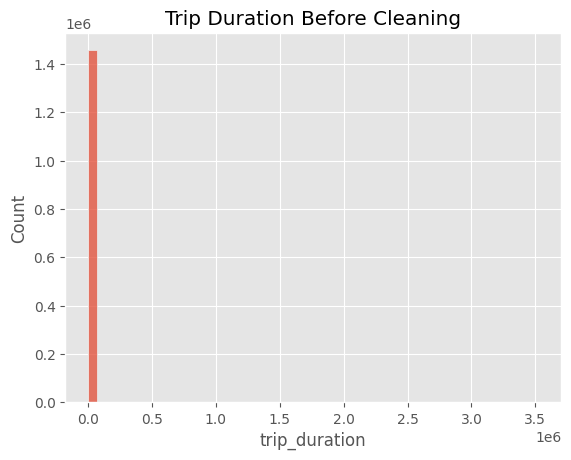

In [ ]:
label_name = "trip_duration"


import seaborn as sns
import matplotlib.pyplot as plt


sns.histplot(data[label_name], bins=50)

plt.title("Trip Duration Before Cleaning")

plt.show()



this shows single vertical line. It clearly shows that there are some extreme outliers. so these extreme values are stretching the x-axis and making the majority of the data look near zero. that is why all the data looks like on one stright line

In [ ]:
data['trip_duration'].describe(percentiles=[0.01, 0.05, 0.95, 0.99])# want to know some statistics to knowo the spread of data and where the majority of data lies.


,trip_duration
count,1.458644e+06
mean,9.594923e+02
std,5.237432e+03
min,1.000000e+00
1%,8.700000e+01
5%,1.800000e+02
50%,6.620000e+02
95%,2.104000e+03
99%,3.440000e+03
max,3.526282e+06


from summary statistics, I have figured out that the majority of the data lies below 2100-3400 seconds. Because 95th percentile is around at 2100 secinds and 99th percentile is around 3400 seconds. this means that most trips are within this range. But the values that are greater than 3400 are very rare and are extereme outliers.



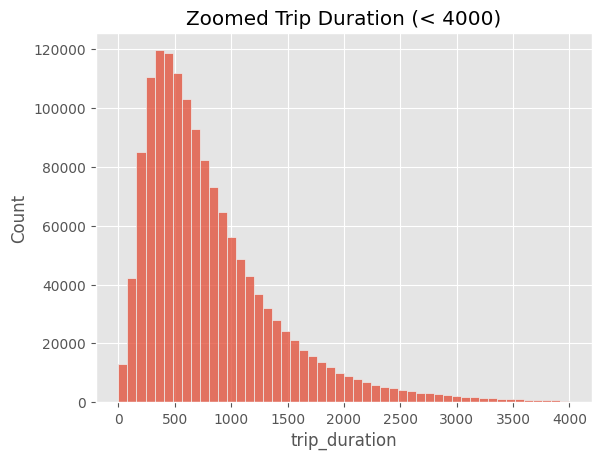

In [ ]:
sns.histplot(data[data['trip_duration'] < 4000]['trip_duration'], bins=50)
plt.title("Zoomed Trip Duration (< 4000)")

plt.show()

Zoom in shows taht msot trips are short, and only few trips are long.

## 2.4 Data Cleaning

In [ ]:
# remove trips that are outliers so that we only work wtih realistic data
data = data[(data['trip_duration'] > 60) & (data['trip_duration'] < 4000)]


print("New shape:", data.shape)

New shape: (1441569, 11)


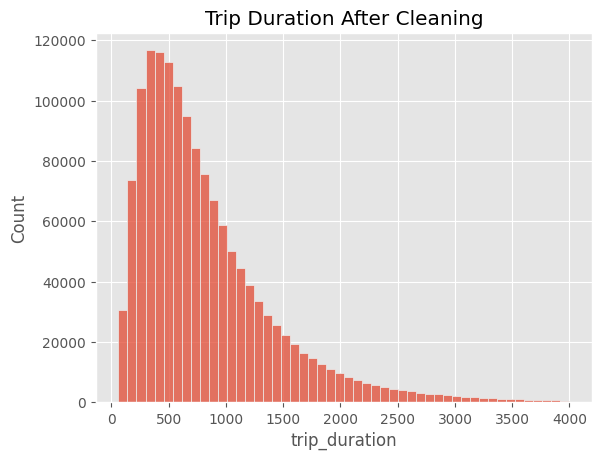

In [ ]:
sns.histplot(data['trip_duration'], bins=50)
plt.title("Trip Duration After Cleaning")

plt.show()

Here we are keeping trips between 60 and 4000 seconds. 60 is because some too short trips also might errors or outliers. it might be noisy so are removing them. After that distribution looks realitic and easy to work with.

## 2.5 Log Transformation

In [ ]:
# log transformation to trip_duration
data['Regression_Label'] = np.log1p(data['trip_duration'])


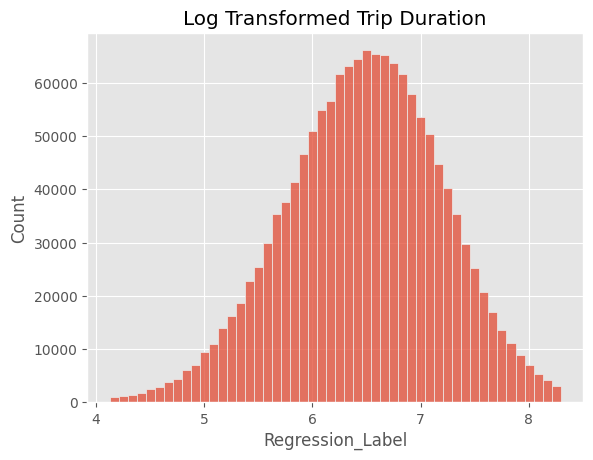

In [ ]:
sns.histplot(data['Regression_Label'], bins=50)
plt.title("Log Transformed Trip Duration")

plt.show()

log transformation is applied here because it reduces skewness and makes our data more balanced. it is important for regression because it helps the model to learn patters better.

## 2.6 Classification Label Creation

In [ ]:
data['Classification_Label'] = pd.qcut(
    data['trip_duration'],
    q=4,
    labels=['Short', 'Medium', 'Long', 'Very Long']
)

In [ ]:

data['Classification_Label'].value_counts()


,count
Classification_Label,
Short,361172
Medium,360625
Very Long,360022
Long,359750


I have divided this into four categories using quantiles. Each category has similar number of samples. So data is balanced and it is good for classfification performance. I am using original trip_duration  not the log-transfomed which is easier to understand and work for classification.

## 3. Feature Engineering and Feature Selection

### 3.1 Time-Based Features

In [ ]:
#Extract time features
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'])

data['hour'] = data['pickup_datetime'].dt.hour


#converting hour to cyclical features
data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)



data['day_of_week'] = data['pickup_datetime'].dt.dayofweek
data['month'] = data['pickup_datetime'].dt.month


data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)

data['is_rush_hour'] = data['hour'].isin([7,8,9,17,18,19]).astype(int)

time-based features were created from the "pick_datatime" column to get features that signal patterns that are related to time.


the hour was extracted first but I converted it further into sine and consine values to represent time as a circluar varaible. (because 23:00 is close to 00:00) but it is stays as hour it will think that 23:00 and 00:00 are far away and treat them differently. so if I represnt as circular variable it will help better understand time relationships.
I also extracted day_of_week and month that capture patterns during different days and seasons. and 2 more "is_weekend" and "is_rush_hour" features were created so that we understand the traffic level or common traffic patterns.

### 3.2 Distance Feature

In [ ]:

# calculating distance using haversine formula

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius(km)
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))



data['distance_km'] = haversine(
    data['pickup_latitude'],
    data['pickup_longitude'],
    data['dropoff_latitude'],
    data['dropoff_longitude']
)

new feature "distance_km" was created that tells the distance from pickup and dropoff location using the Haversine formula.

This is very important feature because distance is one of the main factors that affect the trip duration.



In [ ]:
data['distance_km'].describe()

,distance_km
count,1.441556e+06
mean,3.391565e+00
std,3.801784e+00
min,0.000000e+00
25%,1.241887e+00
50%,2.097896e+00
75%,3.855554e+00
max,8.588488e+01


In [ ]:
(data['distance_km'] == 0).sum()

np.int64(4197)

In [ ]:
(data['distance_km'] > 100).sum()

np.int64(0)

In [ ]:
data = data[data['distance_km'] < 100]

In [ ]:
(data['distance_km'] > 100).sum()

np.int64(0)

some trips had zero distance(maybe happened because of very short trips or GPS issues. I kept them because as you can see they are a small portion of the data.

and I check trips that had extremely large distance more than 100km(which are unrealistic for NYC taxi trips, so I removed them)

### 3.3 Feature Verification

In [ ]:
print(data.columns)

data[['hour', 'hour_sin', 'hour_cos', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour', 'distance_km']].head()

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'Regression_Label', 'Classification_Label', 'hour',
       'day_of_week', 'month', 'is_weekend', 'is_rush_hour', 'distance_km',
       'hour_sin', 'hour_cos'],
      dtype='object')


,hour,hour_sin,hour_cos,day_of_week,month,is_weekend,is_rush_hour,distance_km
0,17,-0.965926,-0.258819,0,3,0,1,1.498521
1,0,0.000000,1.000000,6,6,1,0,1.805507
2,11,0.258819,-0.965926,1,1,0,0,6.385098
3,19,-0.965926,0.258819,2,4,0,1,1.485498
4,13,-0.258819,-0.965926,5,3,1,0,1.188588


Here I checked the dataset after feature engineering to make sure that all the new features were correctly created.


The output shows all the features I have created look logical and have valid values.

So feature engineering was successful.

### 3.4 Categorical Encoding

In [ ]:
data['store_and_fwd_flag'] = data['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

In [ ]:
data['store_and_fwd_flag']

,store_and_fwd_flag
0,0
1,0
2,0
3,0
4,0
...,...
1458639,0
1458640,0
1458641,0
1458642,0


In [ ]:
data['store_and_fwd_flag'].value_counts()

,count
store_and_fwd_flag,
0,1433784
1,7772


here "store_and_fwd_flag" was converted from text to numberic values so we can use it in our model.

This feature indicates if the trip record was stored beforer beign sent. which may little bit relate to trip condition and which might say about trip condition. that is why I am keeping it.


### 3.4 Correlation Analysis & Feature Selection

In [ ]:

candidate_features = [

    'passenger_count',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'store_and_fwd_flag',
    'hour_sin', 'hour_cos',
    'day_of_week', 'month',
    'is_weekend', 'is_rush_hour',
    'distance_km'
]

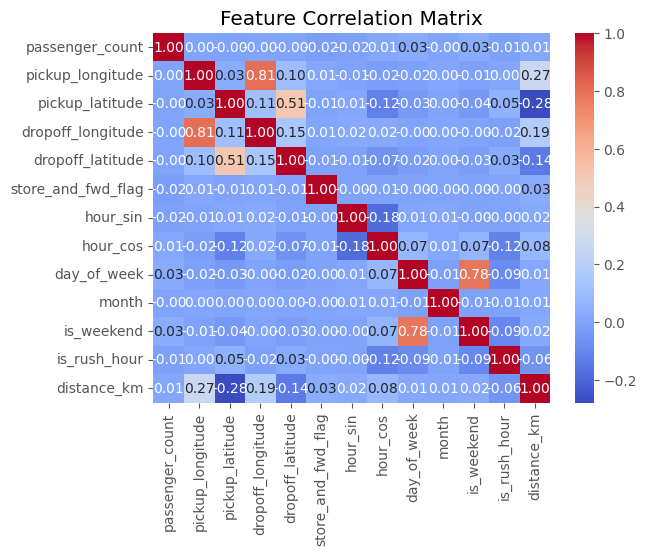

In [ ]:
corr_matrix = data[candidate_features].corr()


sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Feature Correlation Matrix")
plt.show()

this correlation matrix shows how features are correlated(related) to each other. I can see that pickup and drop off coordinates are very corrolated. so they give almost the same infromation. on top of that distance_km already captures this information. so we will remove some repeated features to make the model simpler and better.

### 3.5 Final Selected Features

In [ ]:
removed_features = [

    'pickup_longitude',

    'pickup_latitude',

    'dropoff_longitude',
    'dropoff_latitude',
    'hour',
    'id',
    'pickup_datetime',
    'dropoff_datetime'

]

in this step I removed features that are not useful or are repated.
I am removing hour feature becuase I created better version of using hour_sin and hour_cos. And also id and datetime were removed because they don't help in prediction or may cause data leakage. so final features only have the most important and useful information for predicting trip duration.

In [ ]:
final_features = [

    'passenger_count',

    'store_and_fwd_flag',

    'hour_sin',

    'hour_cos',
    'day_of_week',

    'month',

    'is_weekend',

    'is_rush_hour',
    'distance_km'

]

X = data[final_features].copy()

X.head()

,passenger_count,store_and_fwd_flag,hour_sin,hour_cos,day_of_week,month,is_weekend,is_rush_hour,distance_km
0,1,0,-0.965926,-0.258819,0,3,0,1,1.498521
1,1,0,0.000000,1.000000,6,6,1,0,1.805507
2,1,0,0.258819,-0.965926,1,1,0,0,6.385098
3,1,0,-0.965926,0.258819,2,4,0,1,1.485498
4,1,0,-0.258819,-0.965926,5,3,1,0,1.188588


This table shows tha final features used for building the model.

## 4. Train-Test Split and Normalization

###4.1 Define Labels

In [ ]:
y_reg = data['Regression_Label']

y_clf = data['Classification_Label']

I separate labels for regression and classification tasks

###4.2 Train-Test Split

In [ ]:

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

In [ ]:
print(X_train.shape, X_test.shape)

(1153244, 9) (288312, 9)


In [ ]:
print(y_reg_train.shape, y_clf_train.shape)

(1153244,) (1153244,)


Data spliting into training and testing sets to evaluate performance on unseen data or testing data.

###4.3 Feature Scaling

In [ ]:
scaler = StandardScaler()


X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Features scaled using StandardScaler to improve and make the model do better.

In [ ]:
X_train = pd.DataFrame(X_train, columns=final_features)

X_test = pd.DataFrame(X_test, columns=final_features)

X_train.head()

,passenger_count,store_and_fwd_flag,hour_sin,hour_cos,day_of_week,month,is_weekend,is_rush_hour,distance_km
0,1.015117,-0.073663,-1.136458,-0.247178,-1.049371,-1.495323,-0.632794,1.502037,-0.615612
1,-0.505738,-0.073663,1.350817,-0.881222,-0.537814,-0.305692,-0.632794,1.502037,-0.530087
2,-0.505738,-0.073663,-0.085212,-1.247287,0.996859,0.289123,1.580294,-0.665763,-0.444193
3,-0.505738,-0.073663,-0.751675,1.118996,-1.560929,-0.305692,-0.632794,-0.665763,-0.538549
4,-0.505738,-0.073663,-1.187115,0.118887,0.485302,0.883939,-0.632794,1.502037,-0.658578


In [ ]:
X_train.describe()

,passenger_count,store_and_fwd_flag,hour_sin,hour_cos,day_of_week,month,is_weekend,is_rush_hour,distance_km
count,1.153244e+06,1.153244e+06,1.153244e+06,1.153244e+06,1.153244e+06,1.153244e+06,1.153244e+06,1.153244e+06,1.153244e+06
mean,5.946841e-17,3.253141e-17,-3.953060e-17,2.498696e-17,-9.404536e-17,8.800117e-17,1.343769e-17,-1.292631e-17,-1.018455e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.266166e+00,-7.366298e-02,-1.187115e+00,-1.295481e+00,-1.560929e+00,-1.495323e+00,-6.327938e-01,-6.657627e-01,-8.918003e-01
25%,-5.057385e-01,-7.366298e-02,-9.879371e-01,-8.812219e-01,-1.049371e+00,-9.005078e-01,-6.327938e-01,-6.657627e-01,-5.652784e-01
50%,-5.057385e-01,-7.366298e-02,-8.521170e-02,-2.471782e-01,-2.625603e-02,2.891234e-01,-6.327938e-01,-6.657627e-01,-3.399344e-01
75%,2.546895e-01,-7.366298e-02,1.042914e+00,1.118996e+00,9.968594e-01,8.839390e-01,1.580294e+00,1.502037e+00,1.216344e-01
max,5.577685e+00,1.357534e+01,1.786257e+00,1.533255e+00,1.508417e+00,1.478755e+00,1.580294e+00,1.502037e+00,2.169729e+01


Features were scaled using StandardScaler.

The scalar was fitted only to the training data and applied to both training and testing sets. With this we arer avoiding data leakage.

In general as far as I know scaling helps Linear regression or nural networks perform better.

so after scaling features have mean close to 0 and standard deviation close to 1.
you can see the tables structure  after scaling on above cells

# Problem Statement

After completing data preprocessing, feature engineering and scaling, I will restart the problem clearly.

The goal of this project is to predict taxi trip duration ("trip_duration") using machine learning.

Data link:

https://www.kaggle.com/competitions/nyc-taxi-trip-duration/data


### what I am predicting
Regression task:

Predict the exact trip duration


Classification task:

Predict trip duration category(Short, Medium, Long, Very Long)

### Original data
The dataset includes features such as pickup and dropoff locations, timestamps, passenger count, and trip duration.

From these raw features, I created new features like distance_km and time-based features to better represent the data and make it easier for models to understand it and with new created features it has logical relationship with trip_duration.

### Features used

The model uses the following features:

- distance_km  

- hour_sin, hour_cos  

- day_of_week  

- month  

- is_weekend  

- is_rush_hour  

- passenger_count  

- store_and_fwd_flag

### Why this makes sense?
These features have a logical relationship with trip duration:
- distance_km is the most improtant factor because distance usually means longer time
- time-based features (hour, day, rush hour) capture traffic patterns  
- weekend and month capture behavioral and seasonal changes  
- passenger_count may slightly affect trip time (shared rides, stops)  

Overall, these features reflect real-world conditions that affect how long a taxi trip takes. therefore, predicting trip using these features is logical and meaningful.


# 5. Supervised Model Training and Evaluation






###5.1 Regression Models

In [ ]:
from sklearn.linear_model import LinearRegression


lr_model = LinearRegression()
lr_model.fit(X_train, y_reg_train)


y_pred_lr = lr_model.predict(X_test)

### 5.1.1 Evaluate Linear Regression

In [ ]:

# Evaluation Metrics (MSE, MAE, RMSLE)


from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1. Standard metrics (withLOG scale)
mse_lr = mean_squared_error(y_reg_test, y_pred_lr)
mae_lr = mean_absolute_error(y_reg_test, y_pred_lr)

print("Linear Regression MSE (log scale):", mse_lr)
print("Linear Regression MAE (log scale):", mae_lr)


# 2. Converting prediction back to ORIGINAL scale

y_pred_original = np.expm1(y_pred_lr)
y_test_original = np.expm1(y_reg_test)


# 3. RMSLE function

def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))



rmsle_lr = rmsle(y_test_original, y_pred_original)

print("Linear Regression RMSLE:", rmsle_lr)

Linear Regression MSE (log scale): 0.28172781320421536
Linear Regression MAE (log scale): 0.41793281679798294
Linear Regression RMSLE: 0.5307803813294302


Linear Regression was used as the baseline regression model.
For evaluating the model we used metrics such as MSE and MAE with the log-transformed targets. Also because the original dataset instuructions also suggested using RMSLE as a metric I addedd this. On this predictions werre also converted back to the original scale before calculating RMSLE.


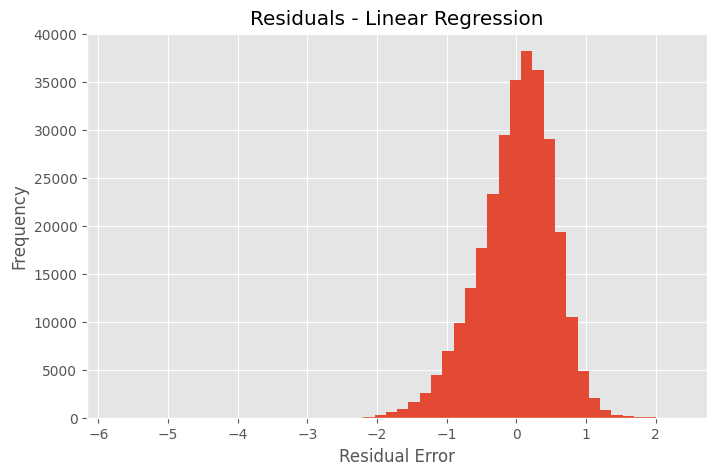

In [ ]:


residuals_lr = y_reg_test - y_pred_lr

plt.figure(figsize=(8, 5))
plt.hist(residuals_lr, bins=50)
plt.title("Residuals - Linear Regression")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.show()






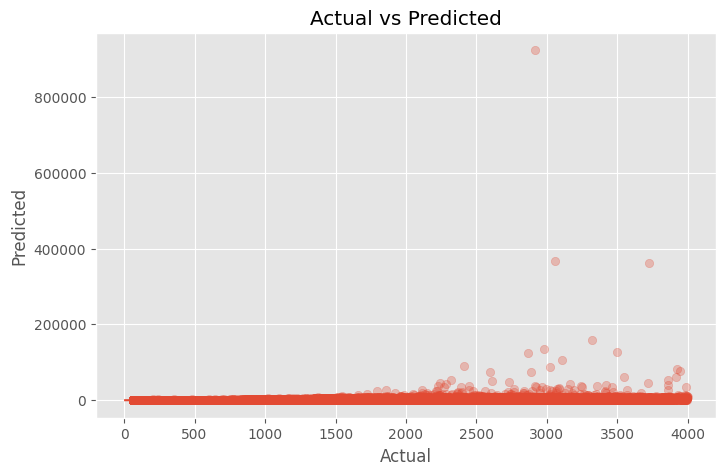

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test_original, y_pred_original, alpha=0.3)
plt.plot([0, y_test_original.max()], [0, y_test_original.max()], '--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

from residual histogram we can see that most errors are close to zero. It clearly indicates that the model performs well for normal trips.
But, for large trip durations, the model tends to understimate values. from actual vs predicted we can see some extreme errors. it shows model struggles with very long trips.

Overall, Linear Regression captures general trends but it struggles in predicting complex patterns.

###5.2 Random Forest Regression

####training the random forest:


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_reg_train)

y_pred_rf = rf_model.predict(X_test)

####Evaluate Random Forest

In [ ]:

mse_rf = mean_squared_error(y_reg_test, y_pred_rf)
mae_rf = mean_absolute_error(y_reg_test, y_pred_rf)


print("Random Forest MSE (log scale):", mse_rf)
print("Random Forest MAE (log scale):", mae_rf)



y_pred_rf_original = np.expm1(y_pred_rf)


rmsle_rf = rmsle(y_test_original, y_pred_rf_original)

print("Random Forest RMSLE:", rmsle_rf)

Random Forest MSE (log scale): 0.1555667151952761
Random Forest MAE (log scale): 0.2997132159806464
Random Forest RMSLE: 0.39441946604506745


The random forest was used as a more advanced regression model. It performs better Linear regression because it can capture non-linear relationships between features and trip duration. these(MSE, MAE, RMSLE) results that Random forest gives more accurate predictions.

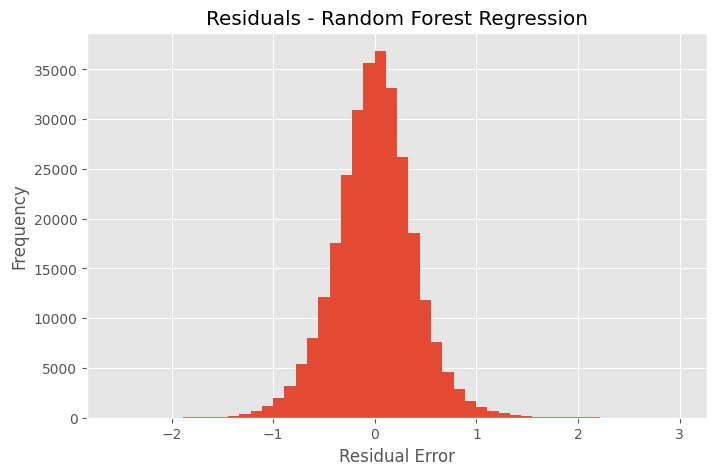

In [ ]:
residuals_rf = y_reg_test - y_pred_rf

plt.figure(figsize=(8, 5))
plt.hist(residuals_rf, bins=50)
plt.title("Residuals - Random Forest Regression")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.show()

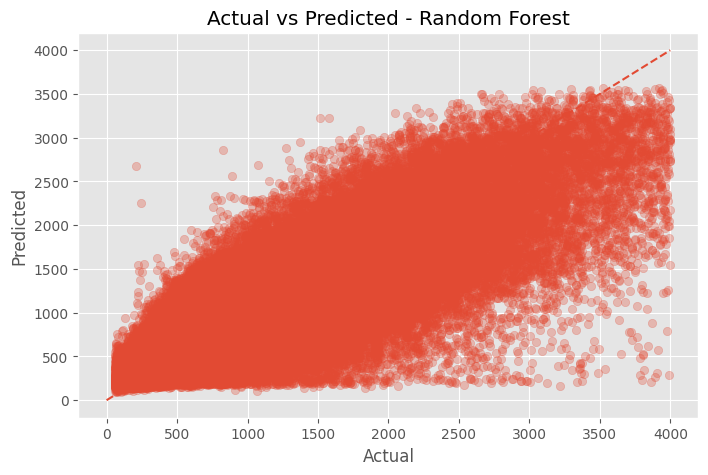

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test_original, y_pred_rf_original, alpha=0.3)
plt.plot([0, y_test_original.max()], [0, y_test_original.max()], '--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted - Random Forest")

plt.show()

The Actual vs Predicted plot shows that Random Forest has better relationship and better performance but it stil has some problems predicting larger values.

Random Forest works better than Linear Regression because it can learn more complex patterns.

From the results, Random Forest has lower error (RMSLE around 0.39) compared to Linear Regression (around 0.53), so it gives more accurate predictions.

The residual plot looks more centered around zero, which means the predictions are more stable.

In the Actual vs Predicted plot, most points follow the diagonal line, so the model is doing a good job overall. But for very long trips, it still makes some mistakes and usually predicts smaller values.

The only downside is that Random Forest takes more time to train.

In [ ]:
import pandas as pd

importance = rf_model.feature_importances_
feature_importance = pd.Series(importance, index=final_features).sort_values(ascending=False)

print(feature_importance)

distance_km           0.895033
hour_cos              0.033804
hour_sin              0.028554
day_of_week           0.022575
month                 0.007642
is_weekend            0.006738
passenger_count       0.003672
is_rush_hour          0.001921
store_and_fwd_flag    0.000060
dtype: float64


From this result of feature importance, we can see that distance_km is the most important feature. which makes sense because longer distance usually means longer trip time.

Time-related features like hour_sin and hour_cos also have some impact, showing that time of day affects trip duration (for example, traffic).

Other features like passenger_count and store_and_fwd_flag have very small impact so they are not very important for prediction

#6. Supervised Classification Models

##6.1 Logistic Regression (Classification)

In [ ]:
from sklearn.linear_model import LogisticRegression


log_clf = LogisticRegression(max_iter=1000, n_jobs=-1)

log_clf.fit(X_train, y_clf_train)

y_pred_log = log_clf.predict(X_test)

###Evaluate Logistic Regression

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


acc_log = accuracy_score(y_clf_test, y_pred_log)
prec_log = precision_score(y_clf_test, y_pred_log, average='weighted')
rec_log = recall_score(y_clf_test, y_pred_log, average='weighted')
f1_log = f1_score(y_clf_test, y_pred_log, average='weighted')


print("Logistic Regression Accuracy:", acc_log)
print("Precision:", prec_log)
print("Recall:", rec_log)
print("F1 Score:", f1_log)

Logistic Regression Accuracy: 0.5926843142151558
Precision: 0.5957833868857052
Recall: 0.5926843142151558
F1 Score: 0.5911754595763762


##Confusion Matrix

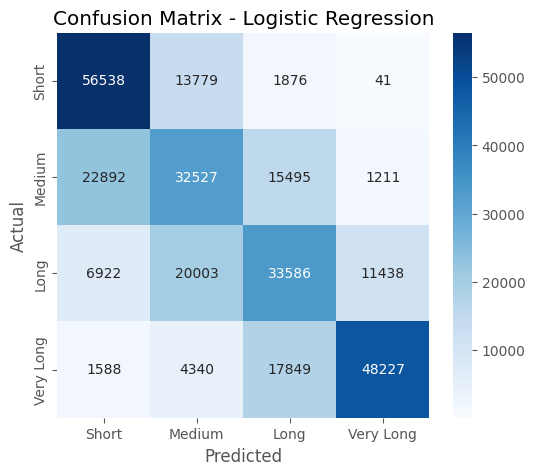

In [ ]:
labels = ['Short', 'Medium', 'Long', 'Very Long']

cm = confusion_matrix(y_clf_test, y_pred_log, labels=labels)


plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)


plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
y_clf_train.value_counts(normalize=True)

,proportion
Classification_Label,
Short,0.250541
Medium,0.250162
Very Long,0.249742
Long,0.249554


We can see that class distruction is balanced. Each class has around 25% of the data.


Logistic Regression was used as the baseline classification model. It got about 59% accuracy and 59% F1 score.

From the confusion matrix, the model does better on Short and Very Long trips. Medium and Long trips are harder to predict because their patterns are more similar and overlap with each other.

Overall Logistic Regression gives a reasonable baseline but it is limited because it is a linear model.

##6.2 MLP Classifier

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_clf_train_encoded = label_encoder.fit_transform(y_clf_train)
y_clf_test_encoded = label_encoder.transform(y_clf_test)

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42,
    early_stopping=True
)



mlp_clf.fit(X_train, y_clf_train_encoded)

y_pred_mlp_encoded = mlp_clf.predict(X_test)

y_pred_mlp = label_encoder.inverse_transform(y_pred_mlp_encoded)

##Evaluation:

In [ ]:
acc_mlp = accuracy_score(y_clf_test, y_pred_mlp)
prec_mlp = precision_score(y_clf_test, y_pred_mlp, average='weighted')
rec_mlp = recall_score(y_clf_test, y_pred_mlp, average='weighted')
f1_mlp = f1_score(y_clf_test, y_pred_mlp, average='weighted')



print("MLP Accuracy:", acc_mlp)
print("Precision:", prec_mlp)
print("Recall:", rec_mlp)
print("F1 Score:", f1_mlp)

MLP Accuracy: 0.6102174033685729
Precision: 0.6111540153867636
Recall: 0.6102174033685729
F1 Score: 0.610111483156538


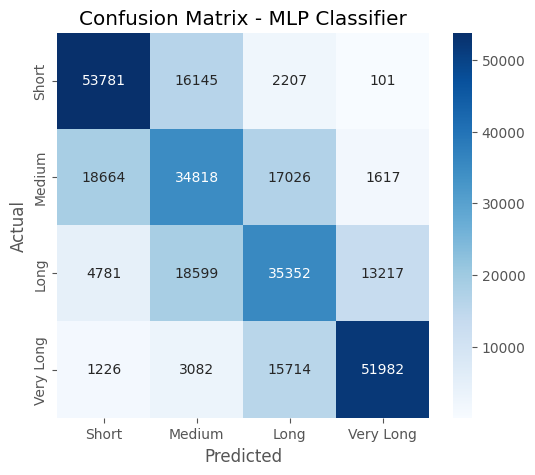

In [ ]:
cm_mlp = confusion_matrix(y_clf_test, y_pred_mlp, labels=labels)


plt.figure(figsize=(6,5))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)


plt.title("Confusion Matrix - MLP Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The MLP model performs a little  better than Logistic Regression.  Accuracy is around 61%, so there is a small improvement.

This makes  sense  because MLP can learn more complex (non-linear) patterns compared to  Logistic regression.

From the  confusion  matrix, we can see that the model still confuses  Medium and Long trips. These  classes are harder to separate because  their features are very similar.

The model  does  better on Short and Very Long trips, since  they are  more different from  each  other.

Overall, MLP improves  performance a bit better , but the problem is  still hard because many  trips look  similar in the data.

##📊 Model Comparison (Classification)

In [ ]:
import pandas as pd


comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'MLP Classifier'],
    'Accuracy': [acc_log, acc_mlp],
    'Precision': [prec_log, prec_mlp],
    'Recall': [rec_log, rec_mlp],
    'F1 Score': [f1_log, f1_mlp]
})


comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.592684,0.595783,0.592684,0.591175
1,MLP Classifier,0.610217,0.611154,0.610217,0.610111


From  the comparison we can see that MLP performs slightly better than Logistic Regression in all metrics.

Logistic Regression gives a good  baseline , but its performance is limited.

MLP improves the  results a bit and gives  higher  accuracy and F1 score.

However, the  improvement  is not very big.  The model still struggle with Medium and Long trips because they are  similar.

Overall, MLP  is the  better model for classification  n this project.

#7. Unsupervised + Supervised Pipeline

In [ ]:
from sklearn.cluster import KMeans

n_clusters = 4

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)


train_clusters = kmeans.fit_predict(X_train)


test_clusters = kmeans.predict(X_test)

##🔹 Step 2: Train Specialized Models per Cluster

Initializing storage

In [ ]:
cluster_models_reg = {}
cluster_models_clf = {}

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPClassifier

for cluster_id in range(n_clusters):


    X_sub = X_train[train_clusters == cluster_id]

    y_reg_sub = y_reg_train[train_clusters == cluster_id]
    y_clf_sub = y_clf_train_encoded[train_clusters == cluster_id]

    #regression model
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
)
    rf.fit(X_sub, y_reg_sub)

    cluster_models_reg[cluster_id] = rf

    # classification model
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=200,
        random_state=42,
        early_stopping=True
    )
    mlp.fit(X_sub, y_clf_sub)

    cluster_models_clf[cluster_id] = mlp

Here I have several number of clusters 3 and 4 and others but it did not really help. The last one I check when Data was split into 4 clusters using KMeans so if you might have a questions why did you choose 4 becuase this was the last one that I tested and all the other clusters like 3 also giving kinda same results. I sticked with 4 because it takes a lot of time to choose 3 and train everything again so I chose 4.

Then, separate models were trained for each cluster

This helps the model learn better from similar trips instead of all data together  .

##🔹 Step 3: Prediction Pipeline (Routing)

###Regression prediction

In [ ]:
import numpy as np

y_pred_reg_cluster = np.zeros(len(X_test))


for cluster_id in range(n_clusters):

    idx = np.where(test_clusters == cluster_id)[0]

    if len(idx) == 0:
        continue

    X_sub = X_test.iloc[idx]


    model = cluster_models_reg[cluster_id]
    y_pred_reg_cluster[idx] = model.predict(X_sub)

###Classification prediction

In [ ]:
y_pred_clf_cluster = np.zeros(len(X_test))

for cluster_id in range(n_clusters):
    idx = np.where(test_clusters == cluster_id)[0]

    if len(idx) == 0:
        continue

    X_sub = X_test.iloc[idx]

    model = cluster_models_clf[cluster_id]
    y_pred_clf_cluster[idx] = model.predict(X_sub)


y_pred_clf_cluster = label_encoder.inverse_transform(y_pred_clf_cluster.astype(int))

##🔹 Step 4: Evaluate Hybrid System

###Regression (RMSLE)

In [ ]:

y_pred_reg_cluster_original = np.expm1(y_pred_reg_cluster)

rmse_cluster = rmsle(y_test_original, y_pred_reg_cluster_original)

print("Clustered Model RMSLE:", rmse_cluster)

Clustered Model RMSLE: 0.39601772174020505


###Classification

In [ ]:
acc_cluster = accuracy_score(y_clf_test, y_pred_clf_cluster)

f1_cluster = f1_score(y_clf_test, y_pred_clf_cluster, average='weighted')

print("Clustered Accuracy:", acc_cluster)
print("Clustered F1:", f1_cluster)

Clustered Accuracy: 0.6098774938261328
Clustered F1: 0.6092081708424021


##🔹 Step 5: Compare vs Baseline

In [ ]:
print("=== Comparison ===")


print("Regression:")
print("Baseline RF RMSLE:", rmsle_rf)
print("Clustered RMSLE:", rmse_cluster)

print("\nClassification:")
print("Baseline MLP Accuracy:", acc_mlp)
print("Clustered Accuracy:", acc_cluster)

=== Comparison ===
Regression:
Baseline RF RMSLE: 0.39441946604506745
Clustered RMSLE: 0.39601772174020505

Classification:
Baseline MLP Accuracy: 0.6102174033685729
Clustered Accuracy: 0.6098774938261328


The clustered model did not improve the results. I thought it would but I also tried differnt values such as different number of clusters and on random forest I changed some parameters but despite that it did not perform better and the one global model worked better for my data. but it gave a close results.

For regression, the clustered model is slightly worse than the normal Random Forest.

For classification, the clustered model is also a bit worse than the normal MLP.

This means clustering  did not really help in this case.

Because the clusters in the data  are not very different from each other, so using one global model works better.

Overall, adding clustering made the model more complex but did not  improve performance and I think for this data it is not that of a useful method.

#6) Conclusion & Justification

In this project, I built different models to predict taxi trip duration using both regression and classification.




For **regression**, **Random Forest** worked the best. It gave lower error compared to Linear Regression because it can handle more complex patterns in the data.

For **classification**, the MLP model performed slightly better than Logistic Regression. It gave a bit higher accuracy and F1 score. It is worth to mention that classification results were about 61% accuracy and F1. It is actually low. the reason is that in general data is chosen for regression but in terms of classficiation there are on the middle hard to seperate values for models.








From feature  importance, **distance_km**  was the most important feature, which makes sense  because longer trips take  more time. Time-related features like hour_sin,  hour_cos, and  day_of_week  also helped since traffic changes during the  day.


**Clustering** did not really help in this project. The clustered model performed about the same or slightly worse than the normal models. This means the data was already simple enough, and splitting it into clusters did not give extra benefit.

From this project, I learned that feature engineering is very important. Raw data is not always useful, and we need to transform it to get better results. For example, converting time into sin and cos helped a lot(which I have never even thought about it before). I also learned how to calculate distance and how to choose better features. MOst importantly saw that when I was working on it at first try I choose or retrieved really bad features that rather distracted or added so much noise and models did not perform well. After trying and thiking on different features I saw that how good features or how effective feature engineering can boost the models performance. These were the things that I think I learnt while working on this project.

If I had more time or more data, I would add more real-world features like traffic, weather, location zones, and road conditions. I think these would help improve the model a lot and make it closer to real systems like Uber or Google Maps.

**Overall, this project helped me understand how machine learning works in real problems and how important data preparation is.**





I learned a lot from this project, and I am very grateful for the opportunity to work on it.